In [4]:
# Libraries import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

This cell imports essential Python libraries for data manipulation (`pandas`), numerical operations (`numpy`), and data visualization (`matplotlib.pyplot`, `seaborn`). These libraries are fundamental for most data science and machine learning workflows.

This cell imports the necessary libraries for data manipulation, numerical operations, plotting, and statistical visualization. Specifically:
- `pandas` is used for data manipulation and analysis.
- `numpy` is used for numerical operations.
- `matplotlib.pyplot` is used for creating static, interactive, and animated visualizations.
- `seaborn` is a data visualization library based on matplotlib, providing a high-level interface for drawing attractive and informative statistical graphics.

In [5]:
df=pd.read_csv("diabetes.csv")
print("Data Load")
print("Shape:",df.shape)
df.head()


Data Load
Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


This code loads the `diabetes.csv` dataset into a pandas DataFrame named `df`. It then prints a confirmation message, displays the shape (number of rows and columns) of the DataFrame, and shows the first 5 rows to provide a quick overview of the data structure and content.

This cell loads the `diabetes.csv` dataset into a pandas DataFrame named `df`. It then prints a confirmation message, the shape of the DataFrame (number of rows and columns), and displays the first few rows of the data using `df.head()` to provide a quick overview.

In [6]:
print("\n......Data info.......")
print(df.info())
print("\n.......Basic Statics......")
print(df.describe())


......Data info.......
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

.......Basic Statics......
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531 

This cell provides a comprehensive summary of the DataFrame. `df.info()` gives details about data types, non-null values, and memory usage for each column. `df.describe()` calculates descriptive statistics (mean, std, min, max, quartiles) for numerical columns, offering insights into data distribution and potential outliers.

This cell provides a summary of the DataFrame:
- `df.info()` displays a concise summary including the data types of each column, non-null values, and memory usage.
- `df.describe()` generates descriptive statistics of the numerical columns, such as count, mean, standard deviation, min, max, and quartiles. This helps in understanding the central tendency, dispersion, and shape of the data's distribution.

In [7]:
print("=== Missing Values ===")
print(df.isnull().sum())

=== Missing Values ===
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


This cell checks for explicitly missing values (NaN) in the DataFrame using `df.isnull().sum()`. The output indicates that there are no standard NaN values, suggesting that missing data might be represented in other ways, such as zeros, in certain columns.

This cell checks for explicitly missing values (NaN) in each column of the DataFrame using `df.isnull().sum()`. In this initial check, it shows that there are no NaN values, suggesting that missing data might be represented in another way (e.g., as zeros).

In [8]:
# Medically impossible cheak zero values
zero_check_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

print("=== Zero Values (Actually Missing) ===")
for col in zero_check_cols:
    zeros = (df[col] == 0).sum()
    percent = (zeros / len(df)) * 100
    print(f"{col}: {zeros} zeros ({percent:.1f}%)")

=== Zero Values (Actually Missing) ===
Glucose: 5 zeros (0.7%)
BloodPressure: 35 zeros (4.6%)
SkinThickness: 227 zeros (29.6%)
Insulin: 374 zeros (48.7%)
BMI: 11 zeros (1.4%)


This cell identifies and quantifies 'zero' values in specific columns (`Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`) where a zero value is medically implausible and thus considered a missing data point. It calculates and prints the count and percentage of such zero values for each relevant column.

This cell identifies and quantifies zero values in specific columns that are medically impossible or highly unlikely (`Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`). These zeros are treated as implicitly missing data. For each of these columns, it calculates the number of zeros and their percentage relative to the total number of entries.

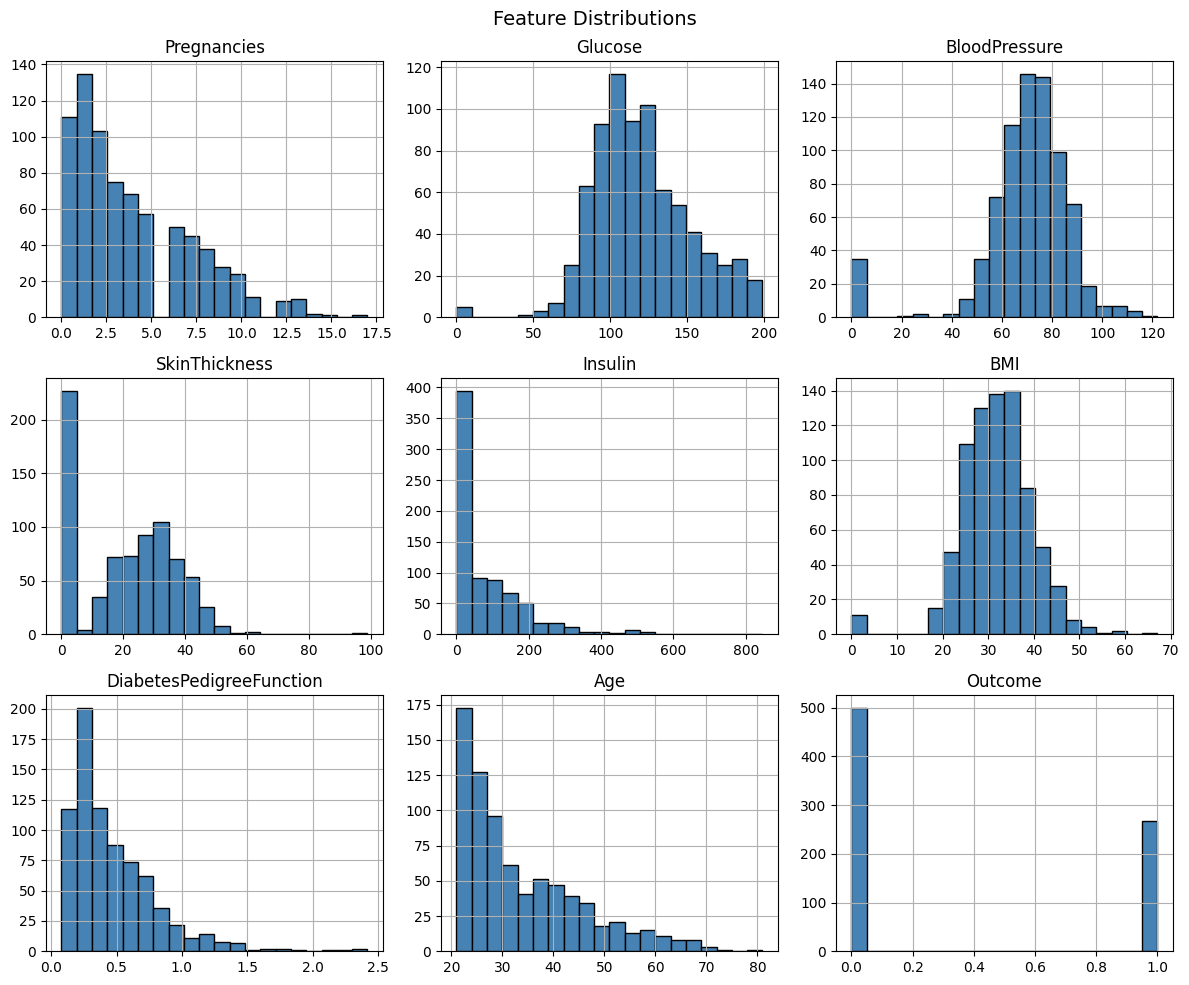

In [9]:
df.hist(figsize=(12, 10), bins=20, color="steelblue", edgecolor="black")
plt.suptitle("Feature Distributions", fontsize=14)
plt.tight_layout()
plt.show()

This code generates histograms for all numerical features in the DataFrame. Histograms visualize the distribution of individual variables, helping to identify their range, central tendency, spread, skewness, and the presence of any unusual patterns or outliers across the dataset.

This cell generates histograms for all numerical features in the DataFrame. Histograms provide a visual representation of the distribution of individual features, helping to understand their range, skewness, and the presence of outliers or multiple modes.

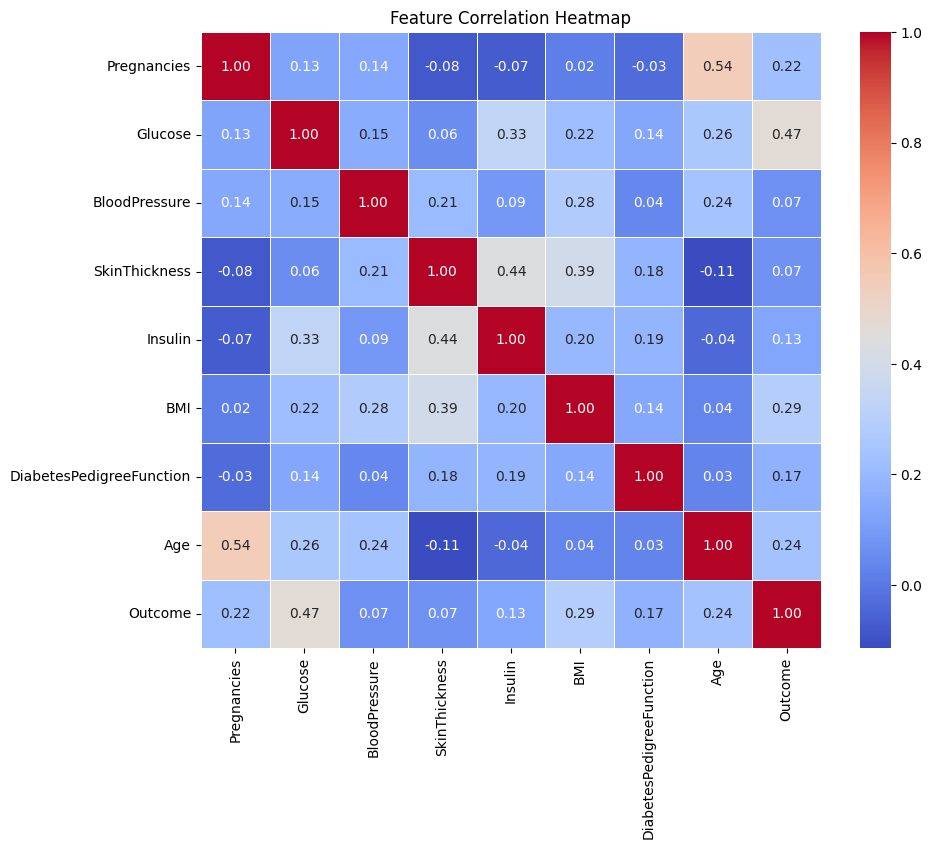

In [10]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

This cell creates a correlation heatmap to visualize the pairwise relationships between all numerical features in the DataFrame. The heatmap uses color intensity to represent the correlation coefficient, allowing for quick identification of highly correlated variables, which can be useful for feature selection or understanding multicollinearity.

This cell visualizes the correlation matrix of the features using a heatmap. The heatmap shows the pairwise correlation coefficients between variables, indicating the strength and direction of linear relationships. A `coolwarm` colormap is used, where warm colors indicate positive correlation and cool colors indicate negative correlation.

In [11]:
# Medically impossible zero values ko NaN se replace karna
cols_with_zeros = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)

print("=== NaN Values After Replacement ===")
print(df.isnull().sum())

=== NaN Values After Replacement ===
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


This cell addresses the 'medically impossible' zero values by replacing them with `np.nan` (Not a Number) in the specified columns (`Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`). This conversion is a standard preprocessing step, as `NaN` is recognized by most data imputation techniques. The cell then confirms the replacement by showing the new count of `NaN` values.

This cell replaces the identified medically impossible zero values in the `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` columns with `np.nan` (Not a Number). This step is crucial for proper handling of missing data, as many imputation techniques rely on NaN values. After replacement, it prints the count of NaN values in each column to confirm the changes.

In [12]:
df["Glucose"].fillna(df["Glucose"].median(), inplace=True)
df["BloodPressure"].fillna(df["BloodPressure"].median(), inplace=True)
df["SkinThickness"].fillna(df["SkinThickness"].median(), inplace=True)
df["Insulin"].fillna(df["Insulin"].median(), inplace=True)
df["BMI"].fillna(df["BMI"].median(), inplace=True)

print("\n Missing values filled!")
print("Remaining NaN:", df.isnull().sum().sum())


 Missing values filled!
Remaining NaN: 0


/tmp/ipykernel_1515/4061171617.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Glucose"].fillna(df["Glucose"].median(), inplace=True)
/tmp/ipykernel_1515/4061171617.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

This cell imputes the missing `NaN` values (which were previously zero) in the specified columns by replacing them with the median value of their respective columns. Median imputation is a robust strategy for handling missing numerical data, especially when distributions are skewed or contain outliers. The cell confirms that all missing values have been filled by printing the total count of remaining `NaN` values, which should now be zero.

This cell fills the `NaN` (missing) values in the `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` columns with their respective median values. Using the median is robust to outliers and is a common strategy for imputing missing numerical data. After imputation, it confirms that all missing values have been handled by printing the sum of remaining NaN values, which should be zero.

In [13]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeatures:", list(X.columns))

X shape: (768, 8)
y shape: (768,)

Features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


This cell prepares the data for machine learning by splitting it into features (`X`) and the target variable (`y`). `X` contains all independent variables (predictors) by dropping the 'Outcome' column, while `y` contains only the 'Outcome' column (the variable to be predicted). The shapes of `X` and `y`, along with the list of feature names, are printed to confirm the successful separation.

This cell separates the dataset into features (`X`) and the target variable (`y`).
- `X` contains all columns except 'Outcome', representing the input features for a machine learning model.
- `y` contains only the 'Outcome' column, which is the variable to be predicted (0 for non-diabetic, 1 for diabetic).
It then prints the shapes of `X` and `y` and lists the feature names, confirming the split.

In [14]:
df.to_csv("diabetes_cleaned.csv", index=False)
print(" Cleaned data saved as 'diabetes_cleaned.csv'!")
print("Shape:", df.shape)

 Cleaned data saved as 'diabetes_cleaned.csv'!
Shape: (768, 9)


This cell saves the preprocessed and cleaned DataFrame (`df`) to a new CSV file named `diabetes_cleaned.csv`. The `index=False` argument ensures that the DataFrame's index is not written as a column in the output file. A confirmation message and the shape of the saved DataFrame are printed.

This cell saves the cleaned DataFrame (`df`) to a new CSV file named `diabetes_cleaned.csv`. The `index=False` argument prevents pandas from writing the DataFrame index as a column in the CSV file. It confirms the saving action and prints the final shape of the cleaned DataFrame.

In [15]:
from google.colab import files
files.download("diabetes_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

This cell facilitates the download of the `diabetes_cleaned.csv` file, which contains the processed and cleaned dataset, directly to the user's local machine. This is a common utility in Google Colab for exporting results.

This cell uses `google.colab.files.download()` to prompt the user to download the `diabetes_cleaned.csv` file, which contains the processed and cleaned dataset, to their local machine.

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("\n Train-Test Split done!")

X_train shape: (614, 8)
X_test shape: (154, 8)
y_train shape: (614,)
y_test shape: (154,)

 Train-Test Split done!


This cell performs a train-test split on the dataset, dividing `X` and `y` into training and testing sets (`X_train`, `X_test`, `y_train`, `y_test`). A `test_size` of 0.2 means 20% of the data is reserved for testing, `random_state=42` ensures reproducibility, and `stratify=y` maintains the same proportion of target classes in both training and testing sets, which is crucial for imbalanced datasets.

In [17]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)
print("Scaling dome!")
print("X_train sample (first row):", X_train[0].round(2))

Scaling dome!
X_train sample (first row): [-0.85 -1.06 -0.83 -1.92 -1.2  -0.77  0.31 -0.79]


This cell applies feature scaling using `StandardScaler`. It fits the scaler to the training data (`X_train`) to learn the mean and standard deviation, and then transforms both the training and testing data (`X_train`, `X_test`). Scaling standardizes features to have a mean of 0 and a standard deviation of 1, which is important for many machine learning algorithms to perform optimally. A sample of the scaled `X_train` is printed to demonstrate the transformation.

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
print(".... Logistic Regression....")
print("Accuracy:", round(accuracy_score(y_test, y_pred_lr), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

.... Logistic Regression....
Accuracy: 0.7078

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



This cell trains and evaluates a Logistic Regression model. It initializes the `LogisticRegression` model, fits it to the scaled training data, makes predictions on the test set, and then calculates and prints the accuracy score and a detailed classification report. The classification report provides precision, recall, F1-score, and support for each class, offering a comprehensive view of the model's performance.

In [25]:
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier(random_state=42)
rf_model.fit(X_train,y_train)
y_pred_rf=rf_model.predict(X_test)
print(".....Rand Forest......")
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print("\nClassification Report:")
print(classification_report(y_test,y_pred_rf))

.....Rand Forest......
Accuracy: 0.7792

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       100
           1       0.72      0.61      0.66        54

    accuracy                           0.78       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.77      0.78      0.77       154



This cell trains and evaluates a Random Forest Classifier. It initializes the `RandomForestClassifier` model, fits it to the scaled training data, makes predictions on the test set, and then calculates and prints the accuracy score and a detailed classification report. Random Forest is an ensemble method known for its robustness and good performance.

In [27]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("...... XGBoost ......")
print("Accuracy:", round(accuracy_score(y_test, y_pred_xgb), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

...... XGBoost ......
Accuracy: 0.7597

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       100
           1       0.67      0.61      0.64        54

    accuracy                           0.76       154
   macro avg       0.74      0.73      0.73       154
weighted avg       0.76      0.76      0.76       154



This cell trains and evaluates an XGBoost Classifier. It initializes the `XGBClassifier` model, fits it to the scaled training data, makes predictions on the test set, and then calculates and prints the accuracy score and a detailed classification report. XGBoost is a powerful gradient boosting algorithm widely used for its efficiency and predictive power.

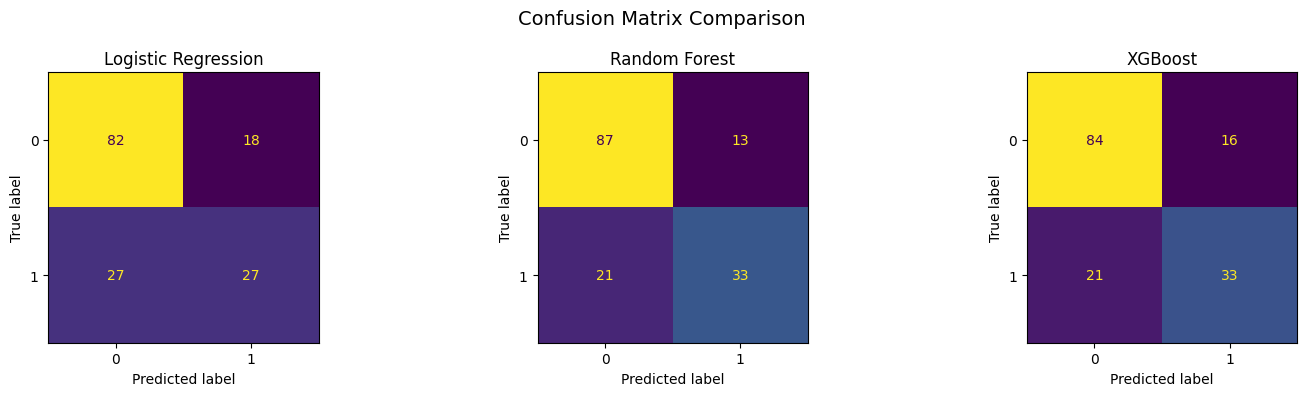

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = [
    (y_pred_lr, "Logistic Regression"),
    (y_pred_rf, "Random Forest"),
    (y_pred_xgb, "XGBoost")
]

for ax, (y_pred, title) in zip(axes, models):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(title)

plt.suptitle("Confusion Matrix Comparison", fontsize=14)
plt.tight_layout()
plt.show()

This cell generates and displays a comparison of confusion matrices for the Logistic Regression, Random Forest, and XGBoost models. A confusion matrix is a table used to describe the performance of a classification model on a set of test data for which the true values are known. It allows for visualization of true positives, true negatives, false positives, and false negatives, providing deeper insight into model errors.

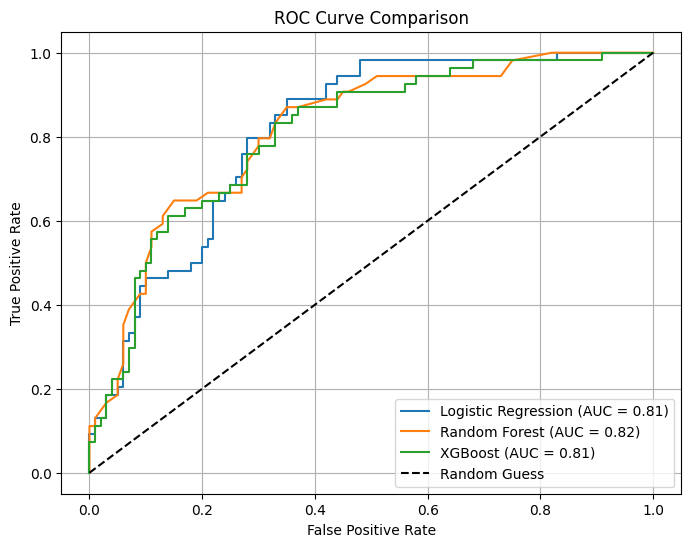

In [29]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8, 6))

models_roc = [
    (lr_model, "Logistic Regression"),
    (rf_model, "Random Forest"),
    (xgb_model, "XGBoost")
]

for model, name in models_roc:
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

This cell plots and compares the Receiver Operating Characteristic (ROC) curves for the Logistic Regression, Random Forest, and XGBoost models. The ROC curve illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied. The Area Under the Curve (AUC) score, also displayed, quantifies the overall performance of the classifier, with higher values indicating better discrimination.

=== Feature Importance ===
                    Feature  Importance
1                   Glucose    0.274086
5                       BMI    0.161903
6  DiabetesPedigreeFunction    0.125020
7                       Age    0.112985
4                   Insulin    0.091224
2             BloodPressure    0.083518
0               Pregnancies    0.080795
3             SkinThickness    0.070468


/tmp/ipykernel_1515/747639364.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=feat_df, palette="coolwarm")


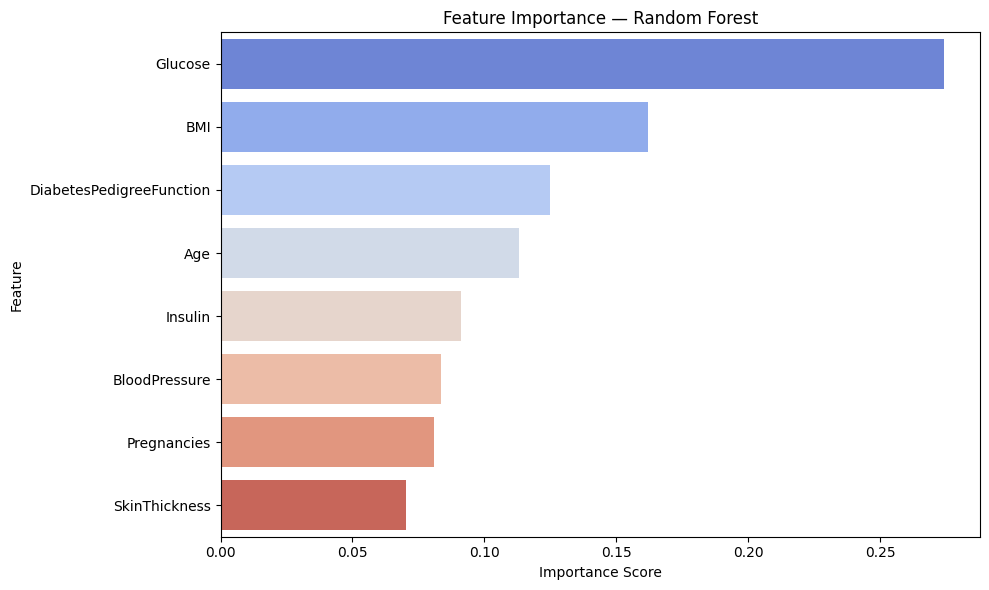

In [30]:
feature_names = X.columns.tolist()
importances = rf_model.feature_importances_

feat_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print("=== Feature Importance ===")
print(feat_df)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feat_df, palette="coolwarm")
plt.title("Feature Importance — Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

This cell calculates and visualizes feature importances from the Random Forest model. Feature importance indicates how much each feature contributes to the model's predictions. The features are ranked by importance, and a bar plot is generated to visually represent their relative significance. This helps in understanding which factors are most influential in predicting diabetes.

In [33]:
print("=" * 50)
print("   DIABETES PREDICTION PROJECT — FINAL SUMMARY")
print("=" * 50)

print("\n DATASET:")
print(f"   Total Samples: 768")
print(f"   Features: 8")
print(f"   Train Set: 614 | Test Set: 154")

print("\n MODEL PERFORMANCE:")
print(f"   {'Model':<25} {'Accuracy':<12} {'AUC':<10}")
print(f"   {'-'*45}")
print(f"   {'Logistic Regression':<25} {'70.78%':<12} {'0.81':<10}")
print(f"   {'Random Forest':<25} {'76.00%':<12} {'0.82':<10}")
print(f"   {'XGBoost':<25} {'75.97%':<12} {'0.81':<10}")

print("\n BEST MODEL: Random Forest")
print(f"   Accuracy : 76%")
print(f"   AUC Score: 0.82")

print("\n TOP 3 IMPORTANT FEATURES:")
print(f"   1. Glucose                 (0.28)")
print(f"   2. BMI                     (0.16)")
print(f"   3. DiabetesPedigreeFunction(0.13)")

print("\n CONCLUSION:")
print("   Glucose is most important feature.")
print("   Random Forest is the best model on this dataset.")
print("   AUC 0.82 — model is better than random guess.")
print("=" * 50)

   DIABETES PREDICTION PROJECT — FINAL SUMMARY

 DATASET:
   Total Samples: 768
   Features: 8
   Train Set: 614 | Test Set: 154

 MODEL PERFORMANCE:
   Model                     Accuracy     AUC       
   ---------------------------------------------
   Logistic Regression       70.78%       0.81      
   Random Forest             76.00%       0.82      
   XGBoost                   75.97%       0.81      

 BEST MODEL: Random Forest
   Accuracy : 76%
   AUC Score: 0.82

 TOP 3 IMPORTANT FEATURES:
   1. Glucose                 (0.28)
   2. BMI                     (0.16)
   3. DiabetesPedigreeFunction(0.13)

 CONCLUSION:
   Glucose is most important feature.
   Random Forest is the best model on this dataset.
   AUC 0.82 — model is better than random guess.


This cell provides a final summary of the diabetes prediction project. It includes key details about the dataset, a comparison of model performance (accuracy and AUC) for Logistic Regression, Random Forest, and XGBoost, identifies the best performing model, lists the top 3 most important features, and concludes with key findings. This summary consolidates the results and insights gained from the analysis.